# Fluid Dynamics Week 3: Coding Exercise
*By Marta Mrozowska, 20/02/2022. Code based on the implementation of equations of motion by James Avery. Exerpts from "Ocean Modelling for Beginners" by Jochen Kämpf have been used throughout the exercise.*

## General Task

In this coding exercise, you will use the *$f$-plane model* to simulate Kelvin waves and the the $\beta$*-plane model* to simulate Rossby waves. Using the results, you will compare the resulting phase speed of the waves with theory.

## About the model

In the absence of viscous forces, advection and the Coriolis effect, for a fluid of constant density:

$\nabla \cdot \textbf{u} = 0 \qquad and \qquad \rho \frac{D\textbf{u}}{Dt} = - \nabla p$

Assuming shallow water, and that the only force acting on the fluid is gravity, the equations of motion can be formulated as follows:

$\frac{\partial u}{\partial t} = -g \frac{\partial \eta}{\partial x}$,

$\frac{\partial v}{\partial t} = -g \frac{\partial \eta}{\partial y}$,

$\frac{\partial \eta}{\partial t} = - \frac{\partial (uh)}{\partial x} - \frac{\partial (vh)}{\partial y}$,

where $t$ is time, $u$ and $v$ are components of horizontal velocity, $g$ is acceleration due to gravity, $\eta$ is sea-level elevation, and $h$ is total water depth.

These shallow water equations can be discreticized:

$u_{i,j}^{n+1} = u_{i,j}^n - \Delta t g (\eta^n_{i+1,j} - \eta^n_{i,j}) / \Delta x$,

$v_{i,j}^{n+1} = u_{i,j}^n - \Delta t g (\eta^n_{i,j+1} - \eta^n_{i,j}) / \Delta y$,

$\eta_{i,j}^* = \eta_{i,j}^n - \Delta t [(h_e u^{n+1}_{i,j} - h_w u^{n+1}_{i-1,j}) / \Delta x - (h_n v^{n+1}_{i,j} - h_s v^{n+1}_{i,j-1}) / \Delta y]$,

where indices $i$ and $j$ correspond to the grid point number in x- and y- directions, respectively, and index $n$ refers to the time-step of the simulation. $\Delta x$, $\Delta y$ and $\Delta t$ are finite differences in distance in x- and y- directions, and time. $h_w$ and $h_e$ are layer thicknesses at the western and eastern faces of the control volume, and $h_s$ and $h_n$ are layer thicknesses at the southern and northern faces of control volume. This odd notation is a result of the implementation of [Arakawa C Grid](https://en.wikipedia.org/wiki/Arakawa_grids).

#### **Shapiro filter**

Working with computer simulations introduces numerical errors, which is why we need to implement a filter which smooths the sea-level elevation:

$\eta_{i,j}^{n+1} = (1-\epsilon) \eta_{i,j}^* + 0.25\epsilon (\eta_{i-1,j}^* + \eta_{i+1,j}^* + \eta_{i,j-1}^* + \eta_{i,j+1}^*)$,

where $\epsilon$ is a small number between 0 and 1 that determines the degree of smoothing.

#### **The Stability Criterion**

In order to ensure that our simulation converges, we use the [CLF condition](https://en.wikipedia.org/wiki/Courant–Friedrichs–Lewy_condition):

$\Delta t \leq \frac{min(\Delta x, \Delta y)}{\sqrt(2gh_{max})}$,

where $h_{max}$ is the maximum water depth encountered in the model domain.

#### **Python is slow with for-loops**

The notation of the discreticized equations of motion suggests the use of three for-loops, one for time and two for x- and y-directions. Python is notoriously slow with for-loops and is much more efficient when array operations are used instead. While in this exercise, the gains of avoiding for-loops are minimal, it is a good coding practice to utilize the array operations instead.

Try to visualize full 2D matrices of *u*, *v* and $\eta$ values. The difference $(\eta^n_{i+1,j} - \eta^n_{i,j})$ can be expressed as subtracting the inner elements of each row of $\eta$ matrix from the elements one grid-step to the right:
```
eta[2:None, :] - eta[1:1, :]
```

By utilizing this type of notation, the code will not only be faster, but also more readable.

#### **$f$-Plane Extension**

Planetary waves "feel" the Coriolis force, contrary to low frequency gravity waves. In this frequency regime, the geostrophic balance allows for a gravity wave which slides along the boundry: a Kelvin wave.

Including the Coriolis force in the equations of motion yields:

$\frac{\partial u}{\partial t} - fv = -g \frac{\partial \eta}{\partial x}$,

$\frac{\partial v}{\partial t} + fu = -g \frac{\partial \eta}{\partial y}$,

where $f$ is the Coriolis parameter. In the Kelvin regime, we will use the *$f$-plane approximation*, ie. we will assume that $f$ is constant.

#### **The Numerical Issue With *f***

The regime simulates a rotating frame of reference. It turns out that simply implementing $f$ as stated above leads to an error which accumulates with every timestep: the path of the fluid particle should be circular in the xy-plane, but ends up a spiral. This is because on planetary scales, the distance between grid points and the corresponding time steps are far from infinitesimal, which results in a numerical error. Because of this, with each cycle in the inertial frame of reference, the fluid particle does not end up in the same spot on its theoretical circular flow path.

In order to combat this, we implement the following correction:

$u_{i,j}^{n+1} = [u_{i,j}^* - B u^n_{i,j} + A v^n_{i,j}] / (1 + B)$,

$v_{i,j}^{n+1} = [v_{i,j}^* - B v^n_{i,j} - A u^n_{i,j}] / (1 + B)$,

where $A = \Delta t f$ and $B = 0.25 A^2$. Here, $u_{i,j}^*$ and $v_{i,j}^*$ are the first guesses for $u$ and $v$, which are simply the $u_{i,j}^n$ and $u_{i,j}^n$ that we can calculate without the regard for Coriolis effect.

#### **$\beta$-Plane Extension**

The dispersion relation of Rossby waves is proportional to $\beta = \frac{\partial f}{\partial y}$. Hence, when we set $f$ to be constant for all latitudes, the Rossby wave will stand still (you can check this by running the Rossby regime with `beta` set to zero). In order to put our Rossby wave to motion, we need to make $f$ change with latitude, and the simplest way to do this is to use the Taylor expansion around a latitude $\phi$. This yields:

$f \approx f_0 + \beta y$,

where $\beta$ is a constant. In the model, this relation is achieved by letting $A$ and $B$ vary with latitude (alongside the $y$-direction of the rectangular basin).

In [43]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import animation

In [44]:
def run_model (dx, Lx, eta0, Nit=100000):

    # define slices
    M = slice(1, -1)
    L = slice(0, -2)
    R = slice(2, None)


    # define difference functions
    def Dx0 (h, dx):
        return 1/dx * (h[R] - h[M])


    def Dx1 (u, dx):
        return 1/dx * (u[M] - u[L])


    # def Dy0 (h, dy):
    #     return 1/dy * (h[M,R] - h[M,M])


    # def Dy1 (v, dy):
    #     return 1/dy * (v[M,M] - v[M,L])


    #parameters in SI units
    g = 9.81
    depth = 10.0
    epsilon = 0.01
    c = np.sqrt(g*depth)
    Nx = int(Lx/dx)
    dt = 0.1*dx/c



    eta = np.zeros(Nx+1)
    eta2D = np.zeros((Nit+1, Nx+1))
    u = np.zeros(Nx+1)


    # initial conditions
    eta = eta0.copy()

    t = 0
    iteration = 0

    while iteration<Nit:

        h = eta + depth

        # update u,v            
        u_t = -g * Dx0(h,dx)
        u[M] += u_t * dt

    
        #update u,v boundary conditions
        u[0] = 0
        u[-1] = 0
    
        
    
        #update h and eta
        u_x = Dx1(u, dx)
        
        h_x = Dx0(h, dx)
        
    
        eta_t = u_x * h[M] + u[M] * h_x 
        eta[M] += -eta_t * dt
        eta[M] = eta[M] * (1-epsilon) + epsilon * 0.5 * (eta[L] + eta[R])
    
        #update eta boundary conditions
        eta[0] = eta[1]
        eta[-1] = eta[-2]
        

        eta2D[iteration] = eta
    
        t += dt 
        iteration += 1

    return eta2D

## Here you can define the parameters and initial conditions for $\eta$.

Note that the current setting is very coarse. The accuracy of the result will depend on the coarsness of the grid. Why? Try to experiment with different grid resolution.

Also note that the initial sea elevation is zero everywhere. Disturbance is needed to put the sea in motion.

In [45]:
# Parameters in SI units

dx = 0.1
Lx = 100
Nx = int(Lx/dx)
center = Nx // 2
width = 55
eta0 = np.zeros((Nx+1))
eta0[center-width:center + width] = 1.0
# * np.exp(-((np.arange(-width, width))**2) / (2 * (width / 3) ** 2))

## Run the model

The model takes $\Delta x$, $\Delta y$, basin dimensions $L_x \times L_y$, $f_0$, $\beta$ and the initial sea elevation $\eta_0$ as function inputs. It also has Kelvin and Rossby switches. Only one of those should be on (equal to 1 or True) at a time. If you switch off both the Kelvin and Rossby regimes, the simulation does not take the Coriolis effect into account and the output will be gravity waves. $\eta_0$ should be an array with the same dimensions as the basin. You decide how the initial sea elevation looks like.

*Hint: plot $\eta_0$ before running the model to check dimensions, make sure it is the desired shape and avoid frustration.*

The output is a 3D array of $\eta(y,x,t)$.

## Plotting the results

There are two plotting functions provided: 2D and 3D. The functions `animate2D` and `animate3D` are iterated over when `animation.FuncAnimation()` is called. The array `frames` tells `FuncAnimation()` which values of `n` to input into the `animate` functions as the animation is created. The array goes from `0` to `10000`. There are 100,000 time steps by default in the `run_model()` function, therefore the upper limit of `frames` cannot extend that limit. The last number in `np.arange()` which defines `frames` is essentially how many frames you wish to skip with every animation step. We want to skip some steps, because some waves - especially planetary waves - are slow. The time step of `run_model()` is by default $\Delta t = 0.1 \cdot \Delta x / c_0$, where $c_0$ is the speed of the shallow water gravity wave. The array `levels` defines the contour levels in the 2D heat map animation. The variable `interval` in `FuncAnimation()` defines the delay between the animated frames in miliseconds.

In [46]:
frames = np.arange(0, 10000, 10)
levels = np.linspace(-2, 5, 20)

In [47]:
eta_xt = run_model(dx, Lx, eta0, Nit=100000)

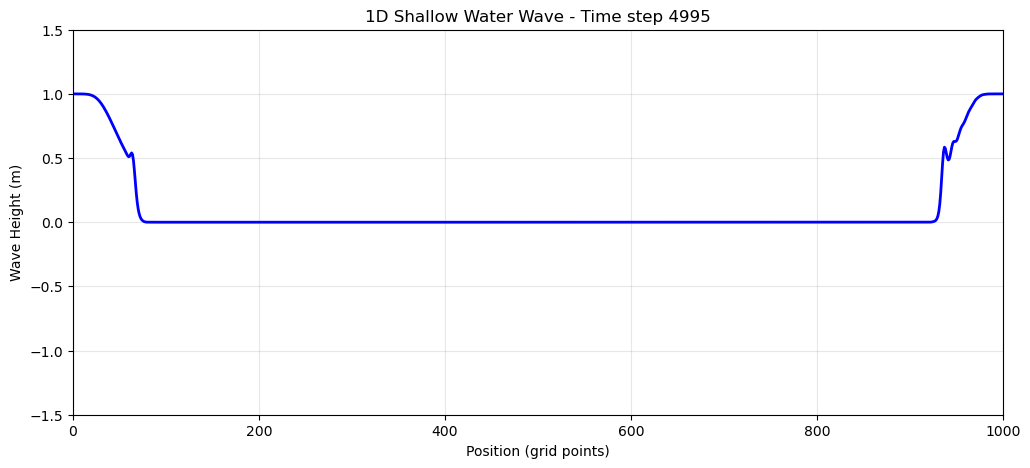

In [48]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(Nx + 1)

def animate1D(n):
    ax.clear()
    
    ax.plot(x, eta_xt[n * 5, :], 'b-', linewidth=2)
    ax.set_xlim(0, Nx)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlabel('Position (grid points)')
    ax.set_ylabel('Wave Height (m)')
    ax.set_title(f'1D Shallow Water Wave - Time step {n * 5}')
    ax.grid(True, alpha=0.3)

ani = animation.FuncAnimation(
    fig, animate1D, frames=np.arange(0, 1000), interval=50)

ani.save("animation1D_wave.gif")
plt.show()

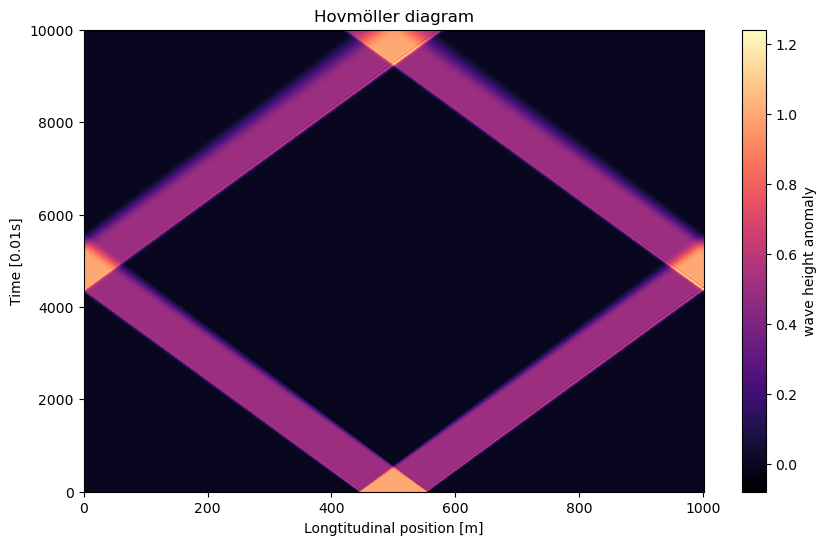

<Figure size 640x480 with 0 Axes>

In [53]:
time_steps = 10000

hovmoller = eta_xt[0:time_steps,:]

plt.figure(figsize =(10,6))
plt.pcolormesh(hovmoller, cmap = "magma")
plt.colorbar(label = "wave height anomaly")
plt.xlabel("Longtitudinal position [m]")
plt.ylabel("Time [0.01s]")
plt.title("Hovmöller diagram")
plt.show()
plt.savefig("Hovmöller")


# Assignment 3, problem 1.4


In [49]:
eta_xt = run_model(dx, Lx, eta0, Nit=100000)

pot = np.mean(eta_xt ** 2) * 9.82 * 1000 * 0.5
print(pot)

202.7338811510429


Text(0.5, 0, 'Time [0.01 s]')

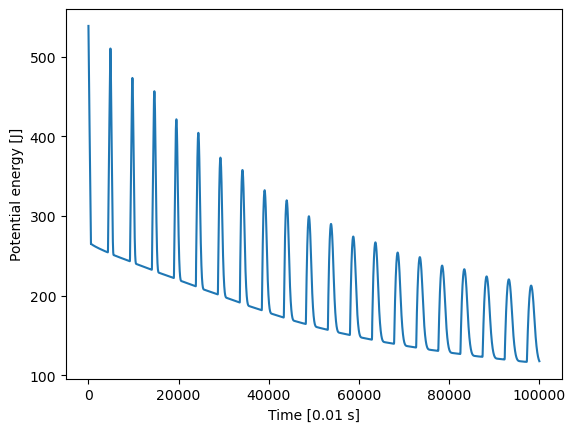

In [50]:
pot = np.mean(eta_xt**2, axis=1)*9.81*1000*0.5
x = np.arange(0, len(pot), 1)
plt.plot(x[:-1], pot[:-1])
plt.ylabel("Potential energy [J]")
plt.xlabel("Time [0.01 s]")


What happens if we double the spatial resolution and halve the temporal resolution? (these changes are made directly in the run_model function)

In [54]:
# Parameters in SI units

dx = 2*0.1
Lx = 100
Nx = int(Lx/dx)
center = Nx // 2
width = 55
eta0 = np.zeros((Nx+1))
eta0[center-width:center + width] = 1.0
# * np.exp(-((np.arange(-width, width))**2) / (2 * (width / 3) ** 2))

In [55]:
eta_xt = run_model(dx, Lx, eta0, Nit=100000)

pot = np.mean(eta_xt ** 2) * 9.82 * 1000 * 0.5
print(pot)

465.84288640183127


Text(0.5, 0, 'Time [0.01 s]')

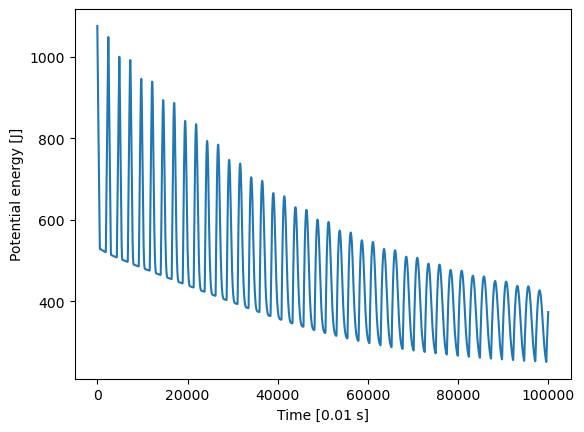

In [56]:
pot = np.mean(eta_xt**2, axis=1)*9.81*1000*0.5
x = np.arange(0, len(pot), 1)
plt.plot(x[:-1], pot[:-1])
plt.ylabel("Potential energy [J]")
plt.xlabel("Time [0.01 s]")